# The pinhole camera

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/magrilu/cv-dojo/blob/main/notebooks/02-camera/camera.ipynb)

Let's start by taking a picture of a simple 3D scene.

A perspective camera is a **projection from 3D space to a 2D image**. In ordinary Euclidean coordinates this projection is not linear: depth matters. Two equal objects at different distances do not have the same image size: what is farther away appears smaller.

Projective geometry gives allow us to model this phenomenon using a linear projection. Instead of representing a 3D point by only three coordinates,

$$
\mathbf M=(X,Y,Z)^\top,
$$

we append one coordinate and work with the homogeneous point

$$
\widetilde{\mathbf M}=(X,Y,Z,1)^\top \in \mathbb P^3.
$$

Image points will be represented in the same spirit by 3-vectors in $\mathbb P^2$. Once we work in these projective spaces, perspective projection can be written as **matrix multiplication**. The familiar non-linearity (division by depth) appears only when we return to ordinary image coordinates.

We will make this concrete with a small synthetic scene and build the camera as three geometrically different transformations:

$$
\widetilde{\mathbf M}
\xmapsto{\;G\;}
\widetilde{\mathbf M}_c
\xmapsto{\;\widehat P=[I\mid\mathbf 0]\;}
\lambda\widetilde{\mathbf p}
\xmapsto{\;K\;}
\lambda\widetilde{\mathbf m}.
$$

At the end will we compress the whole chain into a unique $3\times 4$ camera matrix

$$
\boxed{\lambda\widetilde{\mathbf m}
=K[I\mid\mathbf 0]G\widetilde{\mathbf M}
=K[R\mid\mathbf t]\widetilde{\mathbf M}.}
$$


In [1]:
# On Colab, fetch the repository. Locally this is a no-op.
import os, subprocess
from pathlib import Path

if "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ:
    if not Path("cv-dojo").is_dir():
        subprocess.run(["git", "clone", "-q", "--depth", "1",
                        "https://github.com/magrilu/cv-dojo.git"], check=True)
    os.chdir("cv-dojo")

ROOT = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "data/dojo_house/ideal_house.json").exists():
        ROOT = p
        break
if ROOT is None:
    raise FileNotFoundError("Could not find data/dojo_house/ideal_house.json")

import json
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = False


def set_axes_equal(ax, pad=0.05):
    """Use the same physical scale on x, y, and z in a Matplotlib 3D axis."""
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()], dtype=float)
    centers = limits.mean(axis=1)
    radius = 0.5 * np.max(limits[:, 1] - limits[:, 0]) * (1.0 + pad)
    ax.set_xlim3d(centers[0] - radius, centers[0] + radius)
    ax.set_ylim3d(centers[1] - radius, centers[1] + radius)
    ax.set_zlim3d(centers[2] - radius, centers[2] + radius)
    ax.set_box_aspect((1, 1, 1))


## Our 3D scene

Our synthetic scene is an **idealized metric model** of an origami house. The real object is slightly bent and asymmetric; here we deliberately start from a clean geometric model.

The coordinate convention is fixed once and will be reused throughout the Dojo:

- $X_0,\ldots,X_3$: bottom rectangle;
- $X_4,\ldots,X_7$: eaves rectangle, with $X_{i+4}$ above $X_i$;
- $X_8,X_9$: the two endpoints of the roof ridge;
- the long wall with the red door is the **front**.

All Euclidean coordinates are in centimetres. The approximate dimensions are $5.0\times3.8$ cm, with wall height $2.4$ cm and total height $4.2$ cm.

Before starting, we lift every Euclidean vertex

$$
\mathbf M_i=(X_i,Y_i,Z_i)^\top
$$

to its homogeneous representative

$$
\widetilde{\mathbf M}_i=(X_i,Y_i,Z_i,1)^\top.
$$

So our ten 3D vertices are stored as ten **4-vectors**. The plot below shows the ordinary 3D representatives obtained by taking the last coordinate equal to one.


{'long_side': 5.0, 'depth': 3.8, 'wall_height': 2.4, 'total_height': 4.2, 'roof_rise': 1.8000000000000003}
Euclidean scene:   X  has shape (10, 3)
Homogeneous scene: Xh has shape (10, 4)
first homogeneous vertex: [0. 0. 0. 1.]


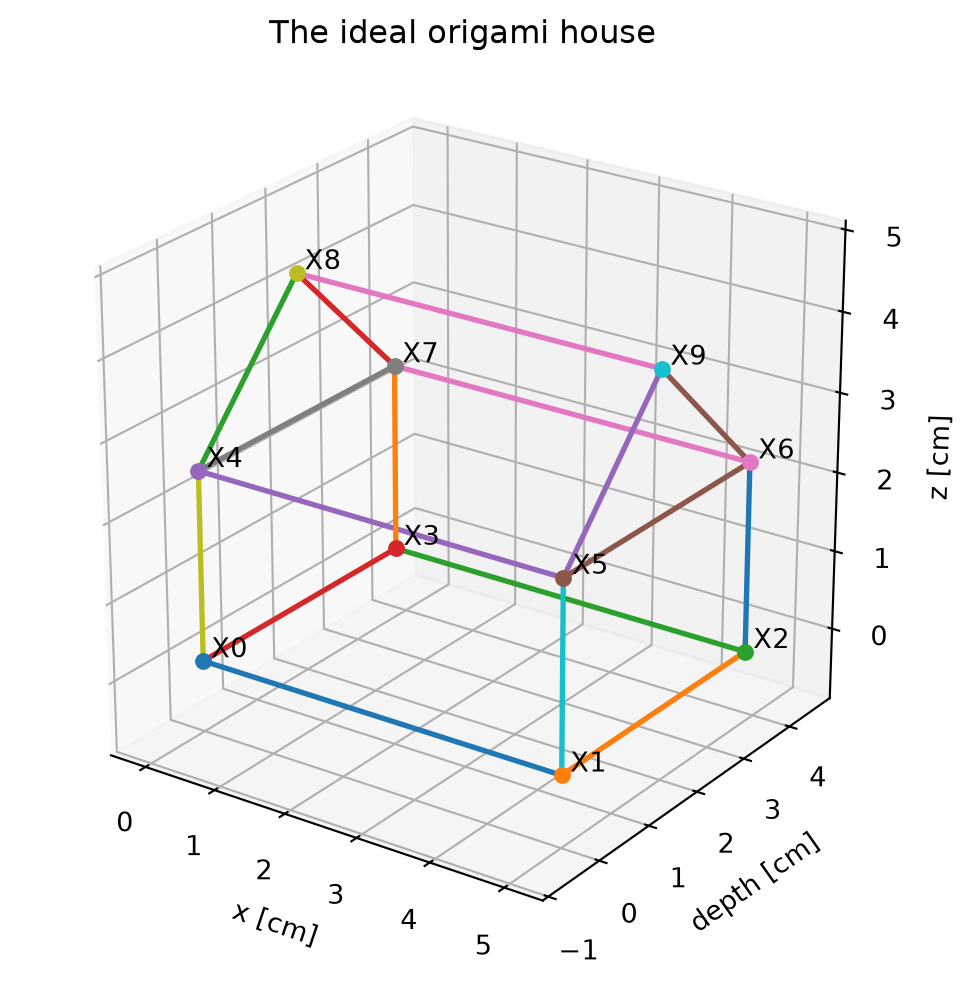

In [2]:
with open(ROOT / "data/dojo_house/ideal_house.json") as f:
    house = json.load(f)

labels = list(house["vertices"])
X = np.array([house["vertices"][k] for k in labels], dtype=float)
Xh = np.c_[X, np.ones(len(X))]   # homogeneous representatives in P^3
index = {k: i for i, k in enumerate(labels)}
edges = house["edges"]

print(house["dimensions_cm"])
print(f"Euclidean scene:   X  has shape {X.shape}")
print(f"Homogeneous scene: Xh has shape {Xh.shape}")
print("first homogeneous vertex:", Xh[0])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
for a, b in edges:
    Pedge = X[[index[a], index[b]]]
    ax.plot(Pedge[:, 0], Pedge[:, 1], Pedge[:, 2], lw=2)
for k, p in zip(labels, X):
    ax.scatter(*p, s=28)
    ax.text(*(p + np.array([0.08, 0.05, 0.05])), k)
ax.set_xlabel("x [cm]")
ax.set_ylabel("depth [cm]")
ax.set_zlabel("z [cm]")
ax.set_title("The ideal origami house")
ax.view_init(elev=24, azim=-55)
set_axes_equal(ax)
plt.show()


## The camera as three transformations

We now send the same homogeneous 3D scene through three maps:

$$
\widetilde{\mathbf M}
\longmapsto
G\widetilde{\mathbf M}
\longmapsto
\widehat P G\widetilde{\mathbf M}
\longmapsto
K\widehat P G\widetilde{\mathbf M}.
$$

They do three different jobs:

1. $G$ changes **3D coordinates** from the world frame to the camera frame.
2. $\widehat P=[I\mid\mathbf 0]$ is the **canonical projective camera**: it maps a point of $\mathbb P^3$ to a homogeneous point of $\mathbb P^2$.
3. $K$ changes **2D image coordinates** from normalized camera coordinates to pixels.



In [3]:
def look_at(camera_center, target, up=np.array([0.0, 0.0, 1.0])):
    """World-to-camera rotation for a camera looking at `target`.

    Camera x points right, y points down in the image, z points forward.
    """
    C = np.asarray(camera_center, float)
    T = np.asarray(target, float)
    z = T - C
    z /= np.linalg.norm(z)
    x = np.cross(z, up)
    x /= np.linalg.norm(x)
    y = np.cross(z, x)
    return np.vstack([x, y, z])


def make_pose(camera_center, target):
    R = look_at(np.asarray(camera_center, float), np.asarray(target, float))
    t = -R @ np.asarray(camera_center, float)
    return R, t


def camera_center(R, t):
    return -R.T @ t


def K_matrix(fx, fy=None, cx=0.0, cy=0.0, skew=0.0):
    if fy is None:
        fy = fx
    return np.array([[fx, skew, cx],
                     [0.0, fy, cy],
                     [0.0, 0.0, 1.0]])


def to_homogeneous(X):
    return np.c_[np.asarray(X), np.ones(len(X))]


def dehomogenize(xh):
    xh = np.asarray(xh, float)
    return xh[..., :-1] / xh[..., -1, None]


def transform_world_to_camera(X, R, t):
    return (R @ np.asarray(X).T).T + np.asarray(t)


def project_normalized(Xc):
    Xc = np.asarray(Xc)
    if np.any(Xc[:, 2] <= 0):
        raise ValueError("Some points are on or behind the camera plane")
    return Xc[:, :2] / Xc[:, 2, None]


def normalized_to_pixels(p, K):
    ph = np.c_[np.asarray(p), np.ones(len(p))]
    xh = (K @ ph.T).T
    return dehomogenize(xh)


def project_points(X, K, R, t):
    Xc = transform_world_to_camera(X, R, t)
    p = project_normalized(Xc)
    return normalized_to_pixels(p, K), Xc


def draw_wireframe_3d(ax, points, labels_on=False, linewidth=1.8):
    first = True
    for a, b in edges:
        Pedge = points[[index[a], index[b]]]
        line, = ax.plot(Pedge[:, 0], Pedge[:, 1], Pedge[:, 2], lw=linewidth)
        if first:
            edge_color = line.get_color()
            first = False
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=18, color=edge_color)
    if labels_on:
        for k, p in zip(labels, points):
            ax.text(*(p + np.array([0.06, 0.06, 0.06])), k, fontsize=8)
    return edge_color


def draw_camera_frame(ax, C, R, axis_length=2.0, label=True):
    """Draw camera centre and its x_c,y_c,z_c axes in world coordinates."""
    C = np.asarray(C)
    basis_world = R.T
    ax.scatter(*C, marker="^", s=70)
    for j, name in enumerate(["x_c", "y_c", "z_c"]):
        end = C + axis_length * basis_world[:, j]
        ax.plot([C[0], end[0]], [C[1], end[1]], [C[2], end[2]], lw=2)
        if label:
            ax.text(*end, name, fontsize=9)
    ax.text(*(C + np.array([0.15, 0.15, 0.15])), "C", fontsize=9)


def draw_image_wireframe(ax, xy, title=None, width=960, height=720):
    edge_color = None
    for a, b in edges:
        q = xy[[index[a], index[b]]]
        line, = ax.plot(q[:, 0], q[:, 1], lw=2, color=edge_color)
        if edge_color is None:
            edge_color = line.get_color()
    ax.scatter(xy[:, 0], xy[:, 1], s=20, color=edge_color)
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.set_xlabel("u [px]")
    ax.set_ylabel("v [px]")
    if title:
        ax.set_title(title)


## 1. From world coordinates to camera coordinates

Let $\widetilde{\mathbf M}=(X,Y,Z,1)^\top$ be a 3D point in the world frame. The camera has its own coordinate system, centred at the optical centre $\mathbf C$.

The first map is a rigid change of coordinates:

$$
\widetilde{\mathbf M}_c
=
G\widetilde{\mathbf M},
\qquad
G=
\begin{bmatrix}
R & \mathbf t\\
\mathbf 0^\top & 1
\end{bmatrix}.
$$

In Euclidean coordinates,

$$
\mathbf M_c=R\mathbf M+\mathbf t
=R(\mathbf M-\mathbf C),
$$

with

$$
\mathbf t=-R\mathbf C,
\qquad
\mathbf C=-R^\top\mathbf t.
$$

With this **world-to-camera convention**, the camera reference frame can be read directly from the rows of $R$. If

$$
R=
\begin{bmatrix}
\mathbf x_c^\top\\
\mathbf y_c^\top\\
\mathbf z_c^\top
\end{bmatrix},
$$

then $\mathbf x_c,\mathbf y_c,\mathbf z_c$ are the three camera axes expressed in world coordinates. Indeed,

$$
\mathbf M_c=
\begin{bmatrix}
\mathbf x_c^\top(\mathbf M-\mathbf C)\\
\mathbf y_c^\top(\mathbf M-\mathbf C)\\
\mathbf z_c^\top(\mathbf M-\mathbf C)
\end{bmatrix}.
$$

Equivalently, the same three axes are the **columns of $R^\top$**. This is why the code below draws the camera frame using `R.T`.

Nothing has been projected yet. The house is still a 3D object: we have only expressed it in another reference frame. Algebraically this is just a change of coordinates, while geometrically we have rototransalted the object.


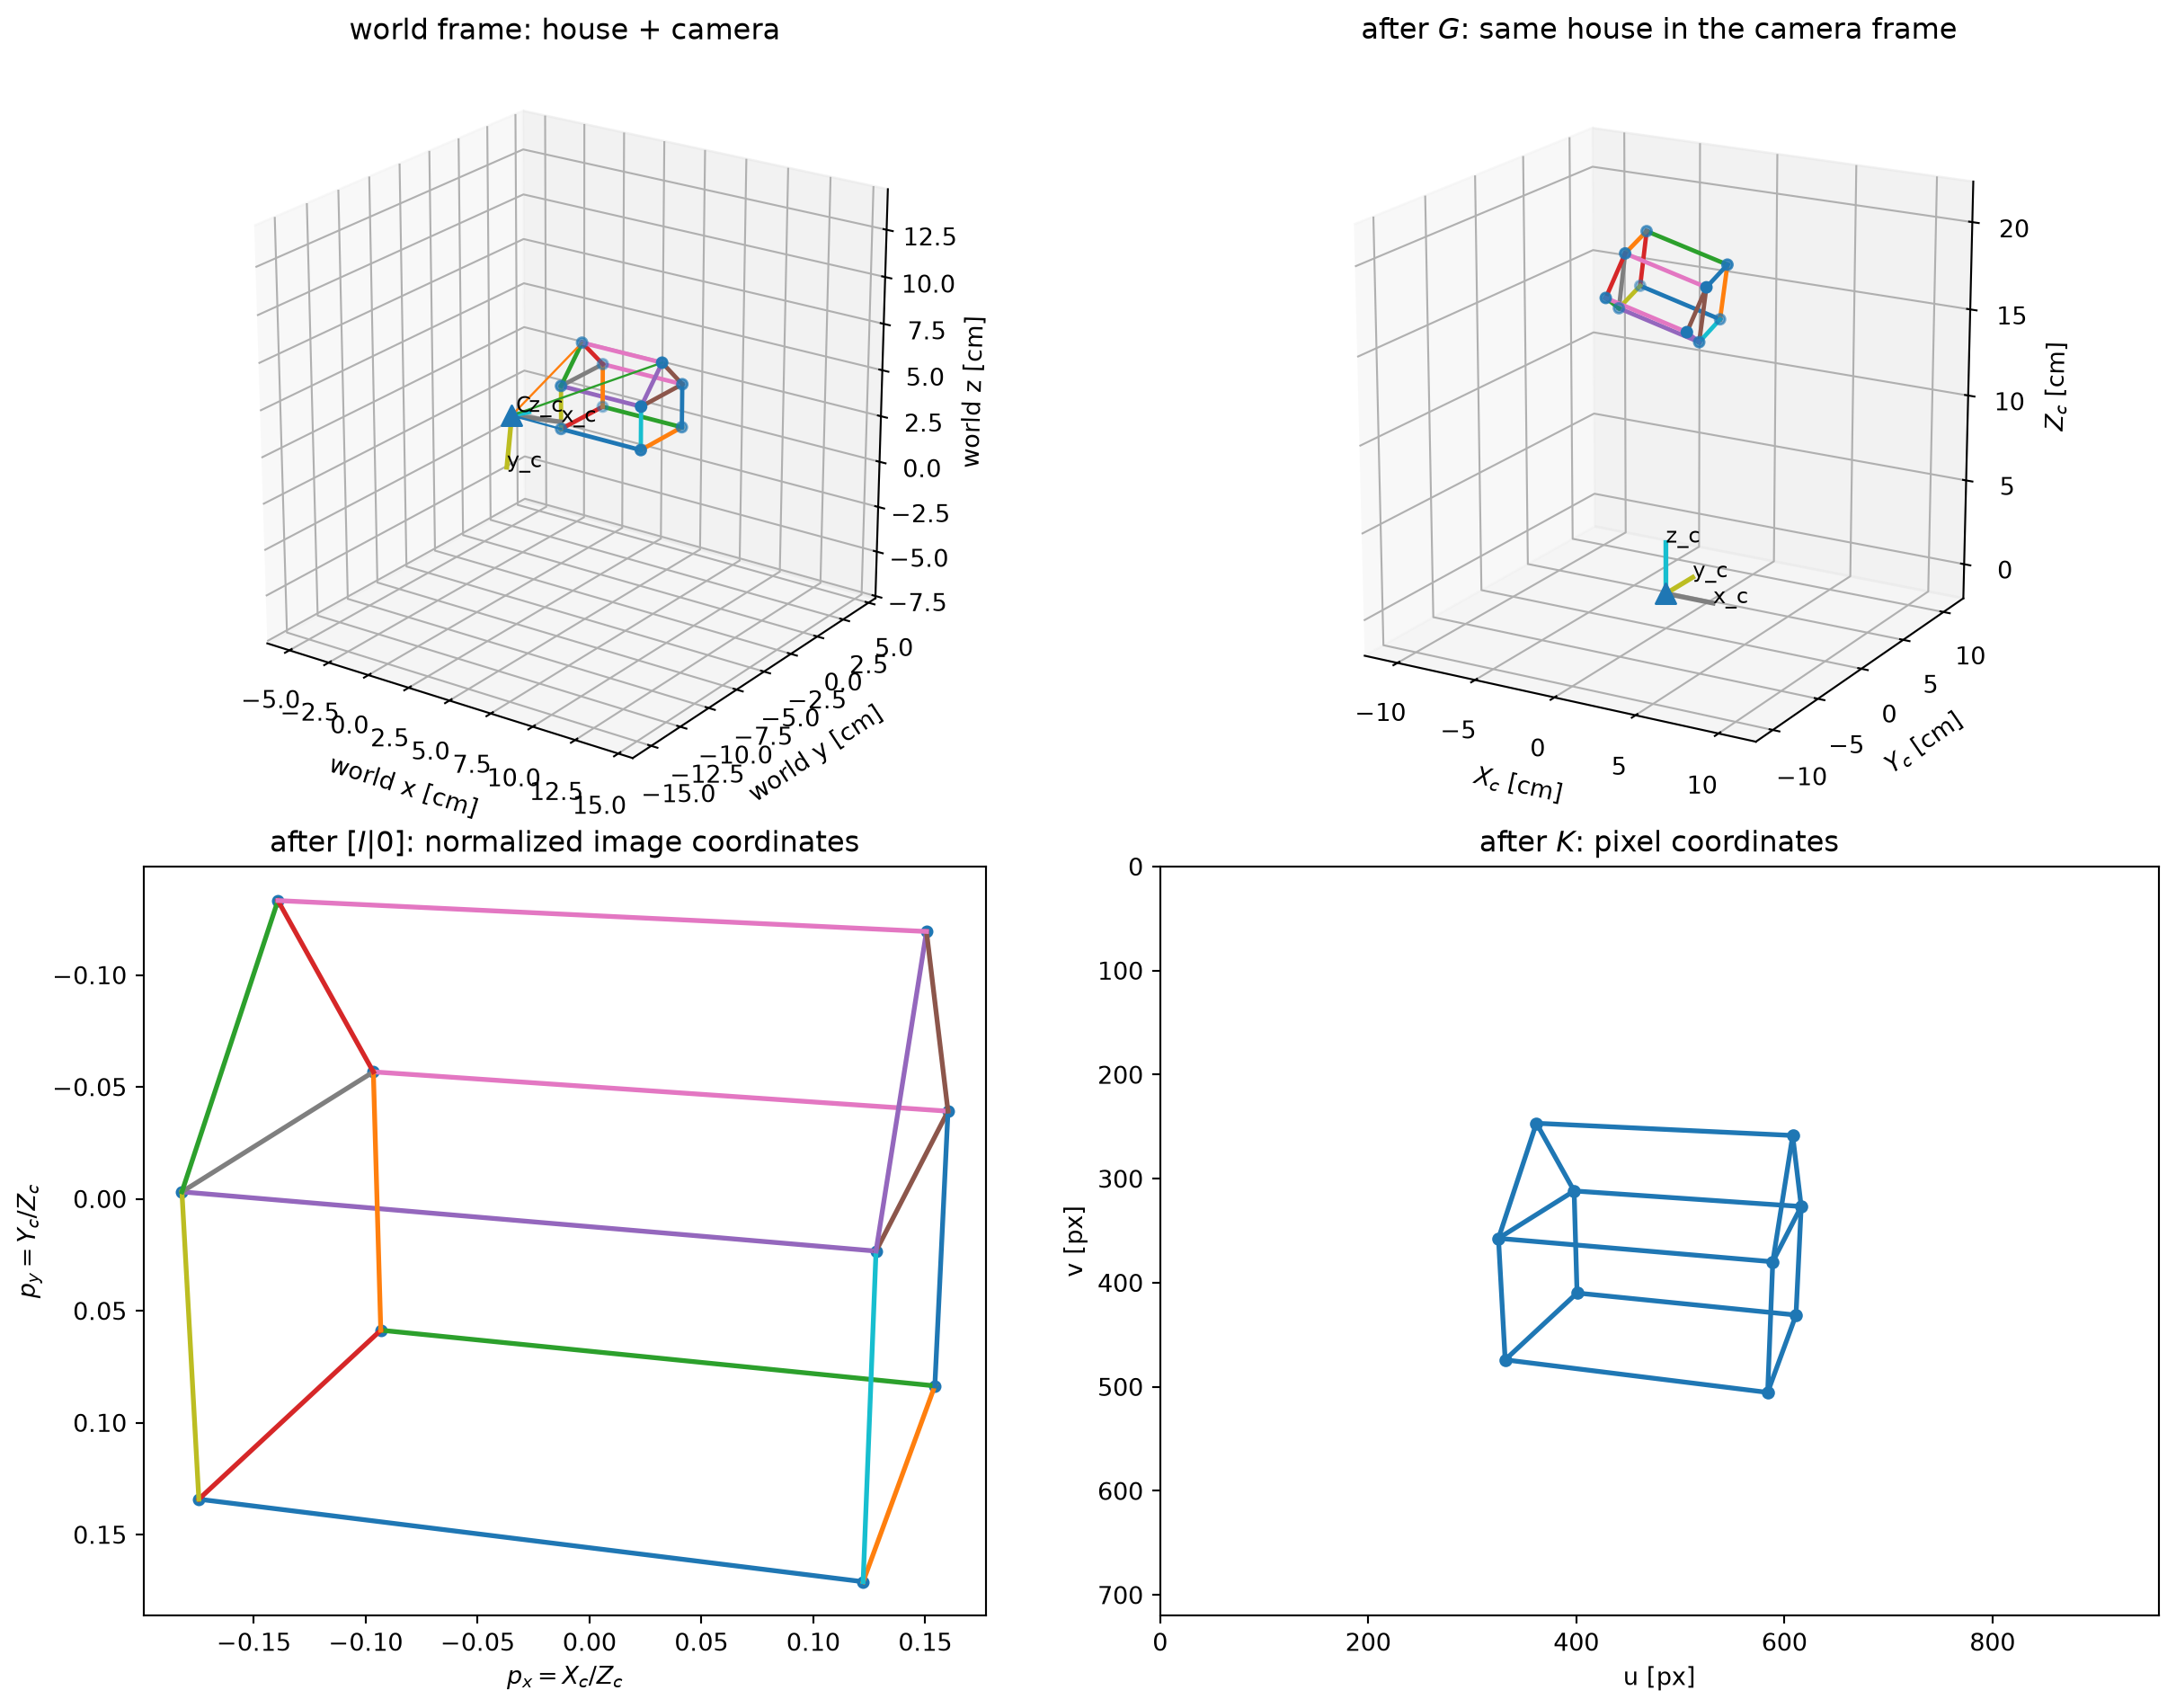

In [4]:
width, height = 960, 720
K = K_matrix(fx=850, cx=width/2, cy=height/2)

target = np.array([2.5, 1.9, 2.0])
R, t = make_pose(camera_center=[7.0, -14.0, 7.0], target=target)
Ccam = camera_center(R, t)
Xc = transform_world_to_camera(X, R, t)
p = project_normalized(Xc)
xy = normalized_to_pixels(p, K)

fig = plt.figure(figsize=(13, 10))

ax = fig.add_subplot(221, projection="3d")
draw_wireframe_3d(ax, X)
draw_camera_frame(ax, Ccam, R, axis_length=2.5)
for j in [index["X0"], index["X8"], index["X9"]]:
    ax.plot([Ccam[0], X[j,0]], [Ccam[1], X[j,1]], [Ccam[2], X[j,2]], lw=0.9)
ax.set_xlabel("world x [cm]")
ax.set_ylabel("world y [cm]")
ax.set_zlabel("world z [cm]")
ax.set_title("world frame: house + camera")
ax.view_init(elev=22, azim=-55)
set_axes_equal(ax)

ax = fig.add_subplot(222, projection="3d")
draw_wireframe_3d(ax, Xc)
ax.scatter(0, 0, 0, marker="^", s=70)
axis_len = 3.0
for j, name in enumerate(["x_c", "y_c", "z_c"]):
    e = np.zeros(3); e[j] = axis_len
    ax.plot([0, e[0]], [0, e[1]], [0, e[2]], lw=2)
    ax.text(*e, name, fontsize=9)
ax.set_xlabel("$X_c$ [cm]")
ax.set_ylabel("$Y_c$ [cm]")
ax.set_zlabel("$Z_c$ [cm]")
ax.set_title("after $G$: same house in the camera frame")
ax.view_init(elev=18, azim=-60)
set_axes_equal(ax)

ax = fig.add_subplot(223)
for a, b in edges:
    q = p[[index[a], index[b]]]
    ax.plot(q[:,0], q[:,1], lw=2)
ax.scatter(p[:,0], p[:,1], s=18)
ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_xlabel("$p_x=X_c/Z_c$")
ax.set_ylabel("$p_y=Y_c/Z_c$")
ax.set_title("after $[I|0]$: normalized image coordinates")

ax = fig.add_subplot(224)
draw_image_wireframe(ax, xy, "after $K$: pixel coordinates", width, height)

plt.tight_layout()
plt.show()


The four panels show the complete chain before we hide it inside one matrix. In the world view we can see the camera centre and the camera axes $\mathbf x_c,\mathbf y_c,\mathbf z_c$; after $G$, the camera centre has become the origin and the optical axis is simply the $z_c$ axis.

## 2. Perspective projection and homogeneous coordinates

Now comes the genuinely projective step. In the camera frame,

$$
\widetilde{\mathbf M}_c=(X_c,Y_c,Z_c,1)^\top.
$$

The canonical camera

$$
\widehat P=[I\mid\mathbf 0]
=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&1&0
\end{bmatrix}
$$

maps the 3D projective point to a **3-vector**:

$$
\mathbf q
=
\widehat P\widetilde{\mathbf M}_c
=
\begin{bmatrix}X_c\\Y_c\\Z_c\end{bmatrix}
=
\lambda\widetilde{\mathbf p}.
$$

This vector is a point of $\mathbb P^2$, not yet a pair of plottable coordinates. Homogeneous vectors are defined only up to non-zero scale, so

$$
\begin{bmatrix}X_c\\Y_c\\Z_c\end{bmatrix}
=
Z_c
\begin{bmatrix}X_c/Z_c\\Y_c/Z_c\\1\end{bmatrix}.
$$

For this representative $\lambda=Z_c$. To return to the ordinary normalized image plane we set the last coordinate to one, i.e. we **dehomogenize**:

$$
\pi\!\left(
\begin{bmatrix}a\\b\\c\end{bmatrix}
\right)
=
\left(\frac{a}{c},\frac{b}{c}\right).
$$

Therefore

$$
(p_x,p_y)
=
\left(\frac{X_c}{Z_c},\frac{Y_c}{Z_c}\right).
$$

This is the key point: perspective projection is not linear as a map between Euclidean spaces, but it **is represented linearly between projective spaces**. The non-linearity reappears only when we choose the Euclidean representative with last coordinate equal to one.


In [5]:
# Follow one house vertex through the canonical projection.
j = index["X9"]
Mc_h = np.r_[Xc[j], 1.0]
P_hat = np.c_[np.eye(3), np.zeros(3)]
q = P_hat @ Mc_h
p_h = q / q[-1]

print("camera-frame homogeneous point M_c =", np.round(Mc_h, 4))
print("q = [I|0] M_c                  =", np.round(q, 4))
print("q / q_3                        =", np.round(p_h, 4))
print("normalized coordinates used in the plot =", np.round(p[j], 4))
print("\nScaling q does not change the plotted point:")
print("pi(q)    =", np.round(dehomogenize(q), 4))
print("pi(7 q)  =", np.round(dehomogenize(7*q), 4))


camera-frame homogeneous point M_c = [ 2.4055 -1.9085 15.9756  1.    ]
q = [I|0] M_c                  = [ 2.4055 -1.9085 15.9756]
q / q_3                        = [ 0.1506 -0.1195  1.    ]
normalized coordinates used in the plot = [ 0.1506 -0.1195]

Scaling q does not change the plotted point:
pi(q)    = [ 0.1506 -0.1195]
pi(7 q)  = [ 0.1506 -0.1195]


### Perspective vs orthographic projection

The division by depth is exactly what creates perspective effects. A useful control experiment is an orthographic camera.

In the **camera reference frame**, orthographic projection simply drops the $z_c$ coordinate: geometrically, every point is projected **parallel to the optical axis $z_c$ onto the camera $x_c y_c$ plane**,

$$
(X_c,Y_c,Z_c)
\longmapsto
(X_c,Y_c).
$$

A scaled orthographic camera adds one global scale factor,

$$
(p_x,p_y)=s(X_c,Y_c),
$$

but still has no point-by-point division by depth. In homogeneous form one convenient orthographic camera is

$$
P_{\mathrm{ortho}}=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&0&1
\end{bmatrix},
$$

because

$$
P_{\mathrm{ortho}}
\begin{bmatrix}X_c\\Y_c\\Z_c\\1\end{bmatrix}
=
\begin{bmatrix}X_c\\Y_c\\1\end{bmatrix}.
$$

Compare this with perspective projection,

$$
(p_x,p_y)=\left(\frac{X_c}{Z_c},\frac{Y_c}{Z_c}\right).
$$

Below we translate the whole house along $z_c$. Under perspective it gets smaller. Under orthographic projection the image is unchanged, because motion perpendicular to the $x_cy_c$ projection plane is discarded.


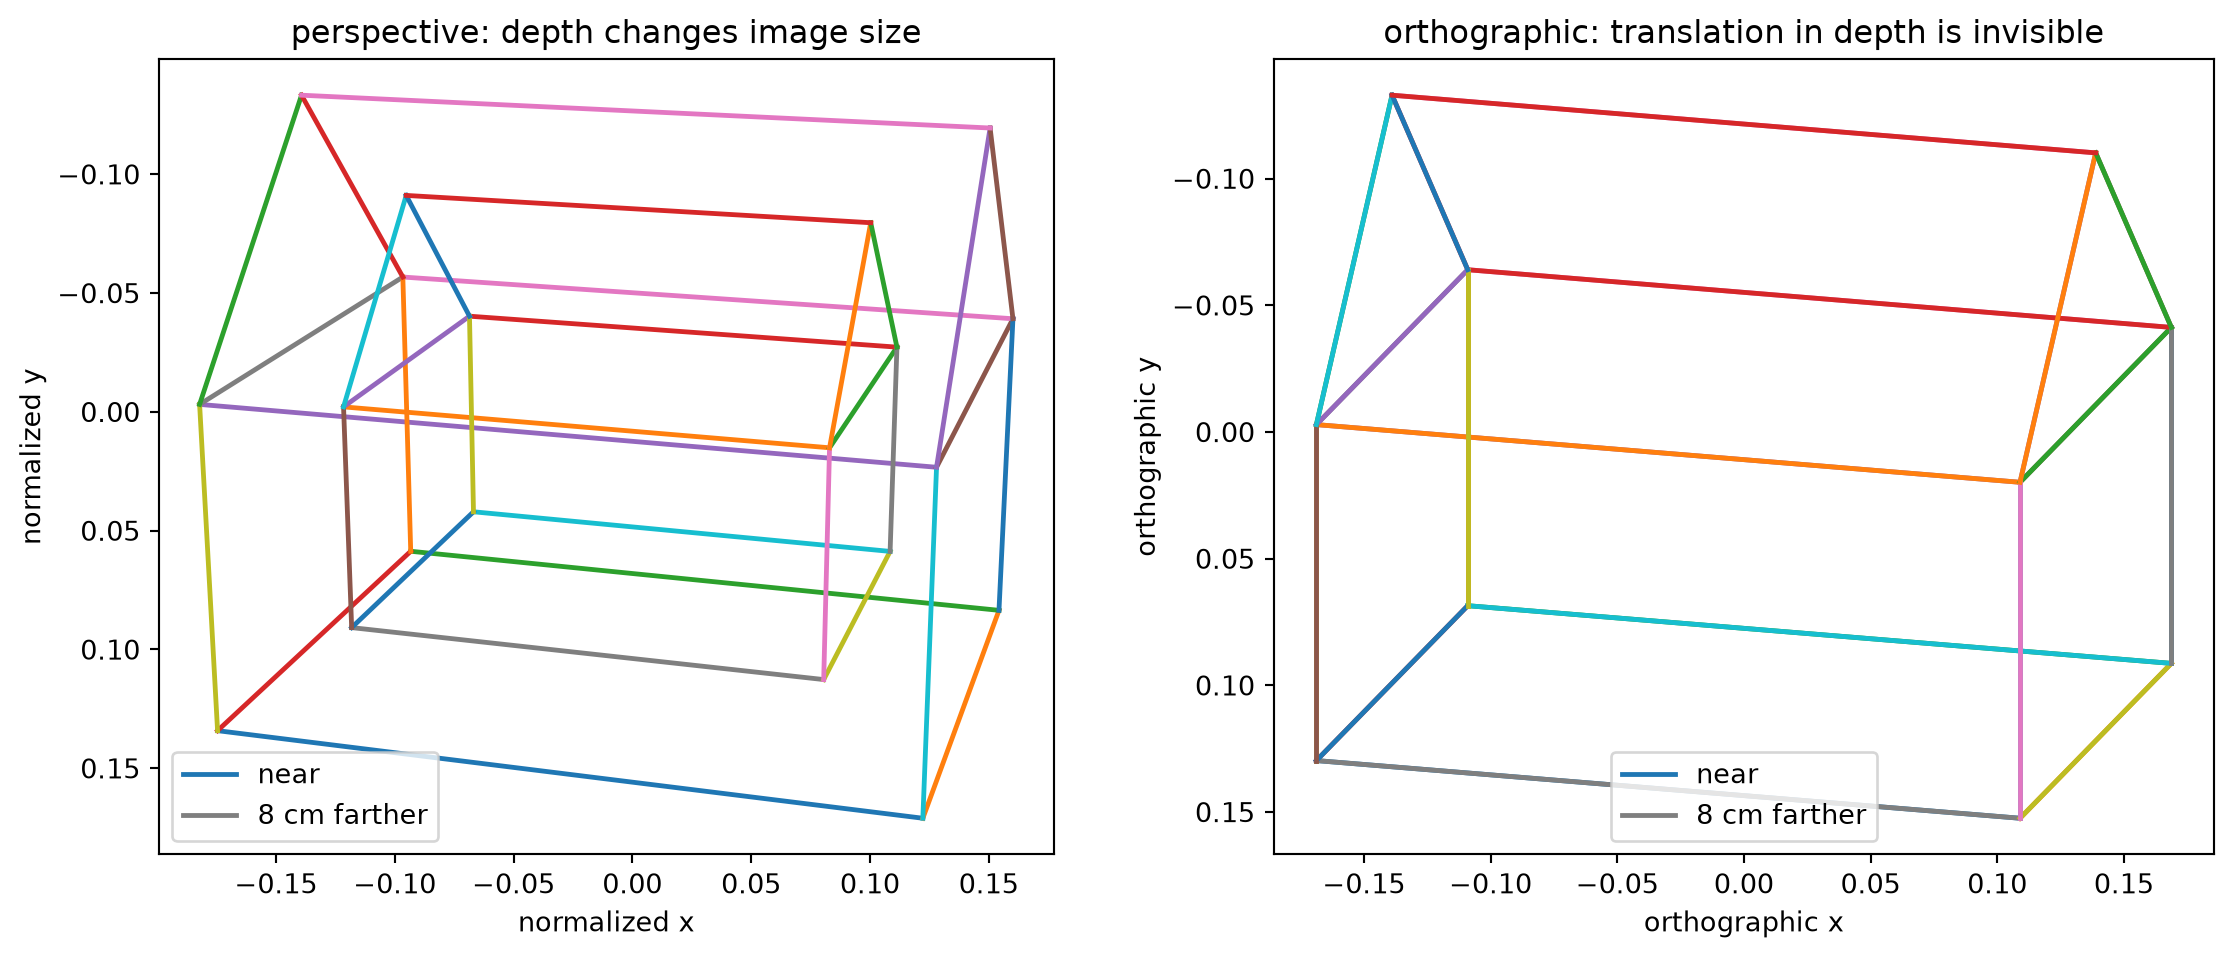

In [6]:
# Compare the same near/far depth change under perspective and scaled orthographic projection.
Xc_near = Xc.copy()
Xc_far = Xc + np.array([0.0, 0.0, 8.0])

p_near = project_normalized(Xc_near)
p_far = project_normalized(Xc_far)

z_ref = Xc_near[:, 2].mean()
s = 1.0 / z_ref
po_near = s * Xc_near[:, :2]
po_far = s * Xc_far[:, :2]   # identical: z translation does not enter

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for pts, label in [(p_near, "near"), (p_far, "8 cm farther")]:
    for a, b in edges:
        q = pts[[index[a], index[b]]]
        axes[0].plot(q[:,0], q[:,1], lw=1.8, label=label if (a,b)==tuple(edges[0]) else None)
axes[0].set_aspect("equal")
axes[0].invert_yaxis()
axes[0].set_title("perspective: depth changes image size")
axes[0].set_xlabel("normalized x")
axes[0].set_ylabel("normalized y")
axes[0].legend()

for pts, label in [(po_near, "near"), (po_far, "8 cm farther")]:
    for a, b in edges:
        q = pts[[index[a], index[b]]]
        axes[1].plot(q[:,0], q[:,1], lw=1.8, label=label if (a,b)==tuple(edges[0]) else None)
axes[1].set_aspect("equal")
axes[1].invert_yaxis()
axes[1].set_title("orthographic: translation in depth is invisible")
axes[1].set_xlabel("orthographic x")
axes[1].set_ylabel("orthographic y")
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. From normalized image coordinates to pixels

The normalized image plane is geometrically convenient, but a digital image uses pixels and an image reference system of its own. The calibration matrix performs this last 2D change of coordinates:

$$
K=
\begin{bmatrix}
f_x&s&c_x\\
0&f_y&c_y\\
0&0&1
\end{bmatrix}.
$$

For a normalized homogeneous point $\widetilde{\mathbf p}=(p_x,p_y,1)^\top$,

$$
\widetilde{\mathbf m}=K\widetilde{\mathbf p}.
$$

The parameters are **intrinsic**: focal length in pixel units, principal point, aspect ratio, and skew. In most modern cameras $s\approx0$ and $f_x\approx f_y$.

So the three transformations are now visible:

$$
\widetilde{\mathbf M}
\xmapsto{G}
\widetilde{\mathbf M}_c
\xmapsto{[I|0]}
\lambda\widetilde{\mathbf p}
\xmapsto{K}
\lambda\widetilde{\mathbf m}.
$$


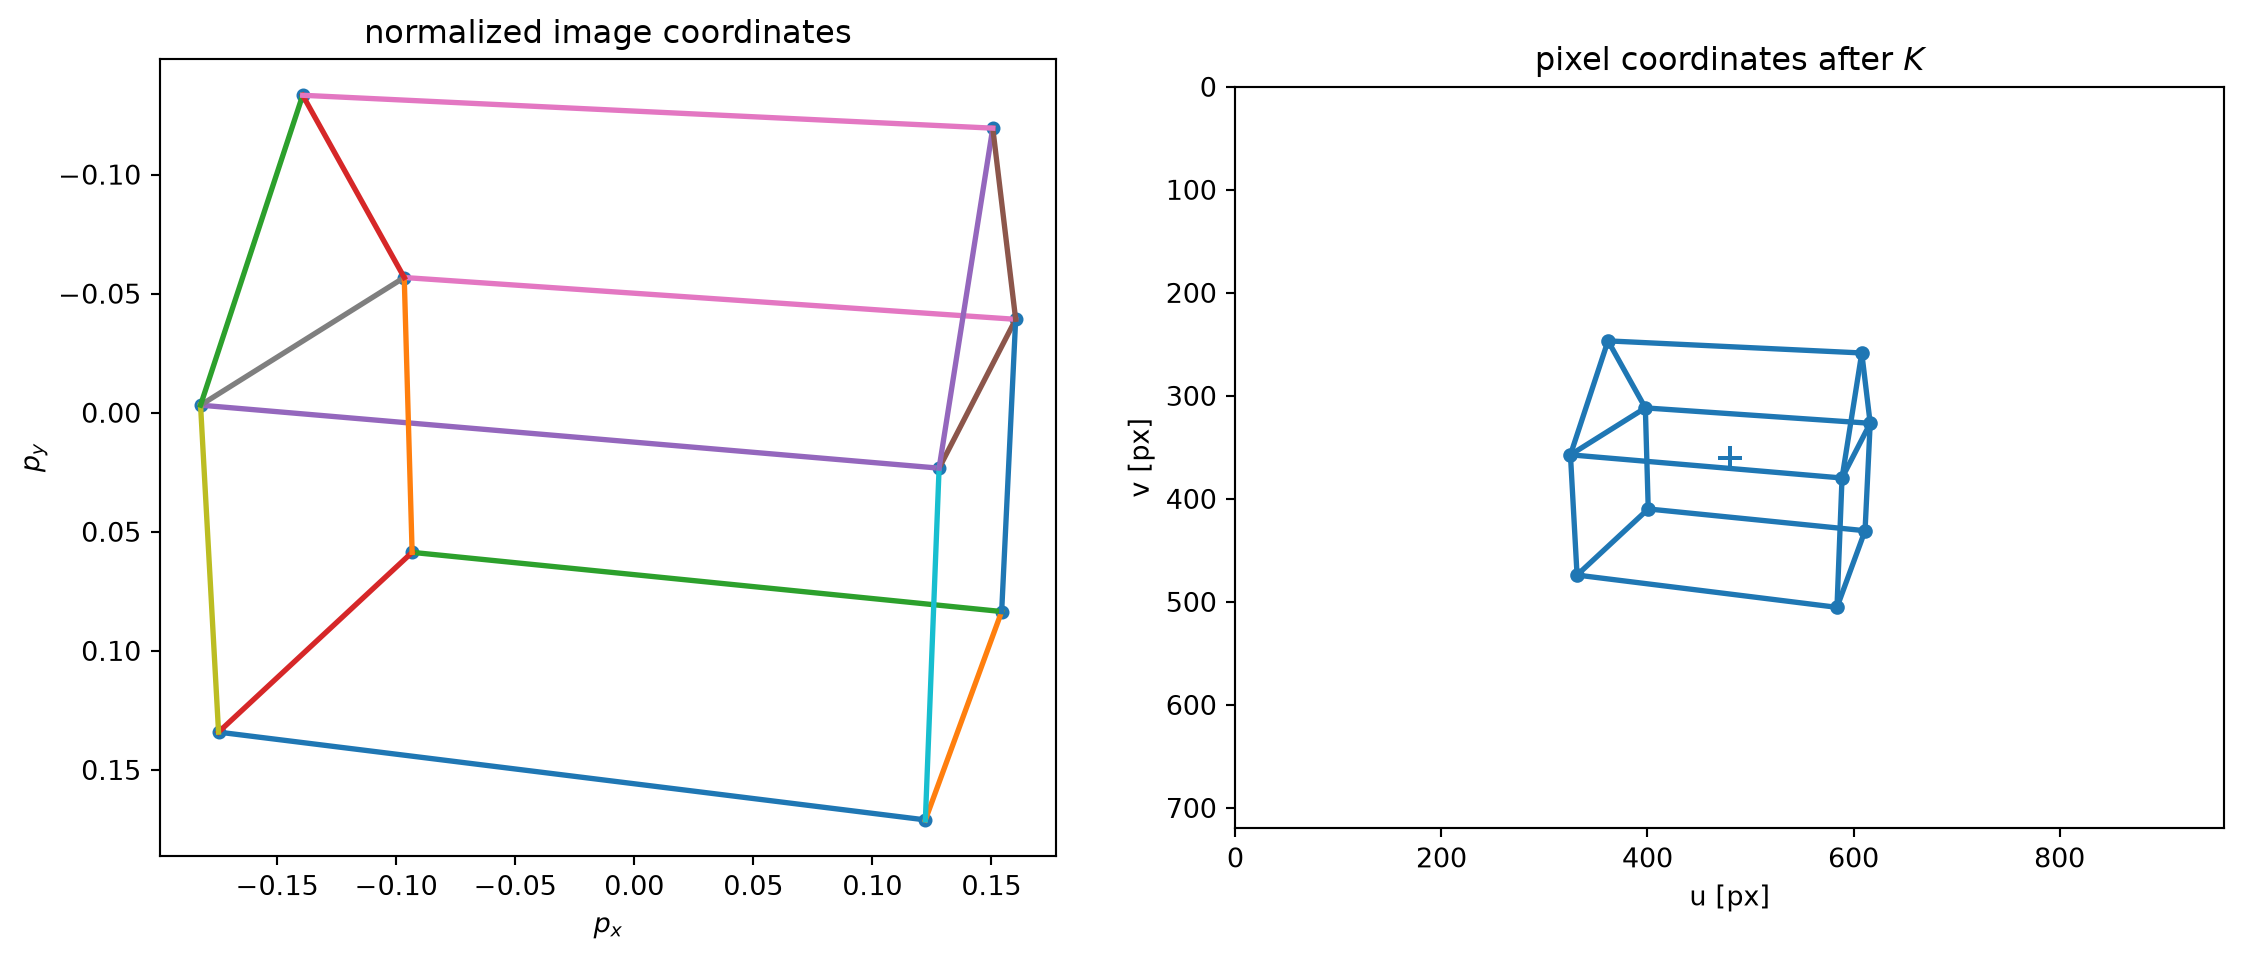

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for a, b in edges:
    q = p[[index[a], index[b]]]
    axes[0].plot(q[:,0], q[:,1], lw=2)
axes[0].scatter(p[:,0], p[:,1], s=18)
axes[0].set_aspect("equal")
axes[0].invert_yaxis()
axes[0].set_xlabel("$p_x$")
axes[0].set_ylabel("$p_y$")
axes[0].set_title("normalized image coordinates")

draw_image_wireframe(axes[1], xy, "pixel coordinates after $K$", width, height)
axes[1].scatter([width/2], [height/2], marker="+", s=80)
plt.tight_layout()
plt.show()


## Put everything together

We can finally collapse the three maps into the standard camera equation:

$$
\lambda\widetilde{\mathbf m}
=K[I\mid\mathbf 0]G\widetilde{\mathbf M}
=K[R\mid\mathbf t]\widetilde{\mathbf M}.
$$

Therefore

$$
P=K[R\mid\mathbf t].
$$

But the factorization is more informative than the product:

- $G$ expresses the 3D scene in the **camera reference frame**;
- $[I\mid\mathbf 0]$ performs the canonical projective map $\mathbb P^3\to\mathbb P^2$;
- dehomogenization chooses the representative with last coordinate one;
- $K$ changes normalized image coordinates into **pixel coordinates**.

The optical centre is the right null-space of $P$:

$$
P\begin{bmatrix}\mathbf C\\1\end{bmatrix}=\mathbf 0.
$$


In [8]:
P = K @ np.c_[R, t]
print("P = K [R | t] =\n", np.round(P, 3))
print("\nP [C,1]^T =", np.round(P @ np.r_[Ccam, 1.0], 10))

# A direct homogeneous check for one point.
Mh = np.r_[X[index["X9"]], 1.0]
y = P @ Mh
pixel_from_P = dehomogenize(y)
print("\nP X9_h =", np.round(y, 3))
print("dehomogenized pixel =", np.round(pixel_from_P, 3))
print("pixel from the staged pipeline =", np.round(xy[index["X9"]], 3))


P = K [R | t] =
 [[ 6.927620e+02  6.735390e+02 -1.390140e+02  5.553317e+03]
 [-2.679700e+01  9.468200e+01 -9.178330e+02  7.937952e+03]
 [-2.610000e-01  9.210000e-01 -2.900000e-01  1.674500e+01]]

P [C,1]^T = [0. 0. 0.]

P X9_h = [9712.993 4128.965   15.976]
dehomogenized pixel = [607.988 258.454]
pixel from the staged pipeline = [607.988 258.454]


## What does focal length do?

Keep the camera pose fixed and change only $f$. The 3D geometry and the camera axes do not move. Only the conversion from normalized image coordinates to pixels changes.


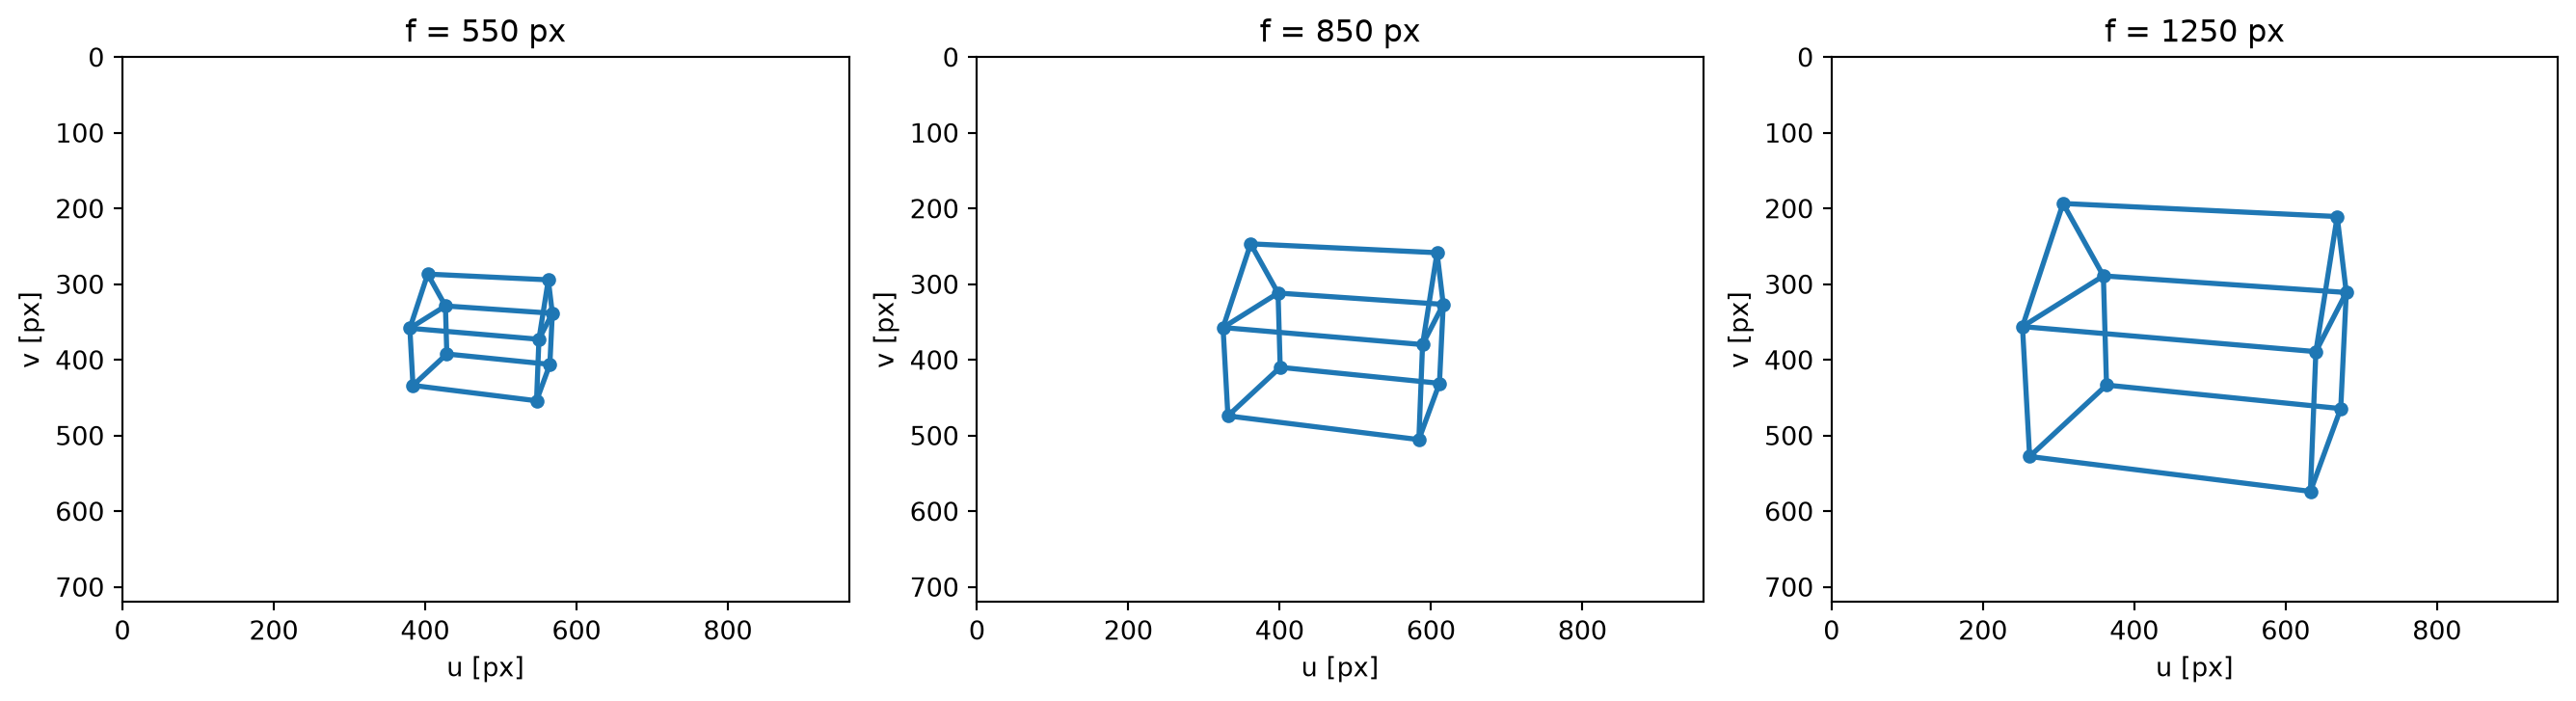

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, f in zip(axes, [550, 850, 1250]):
    Kf = K_matrix(f, cx=width/2, cy=height/2)
    q, _ = project_points(X, Kf, R, t)
    draw_image_wireframe(ax, q, f"f = {f} px", width, height)
plt.tight_layout()
plt.show()


A larger focal length magnifies the projection around the principal point and narrows the field of view. Notice what does **not** change: the camera centre, its axes in 3D, and the normalized image coordinates.


## What does the principal point do?

The principal point is where the optical axis pierces the image plane. Moving $(c_x,c_y)$ changes the 2D image reference system and translates the projected configuration in pixel coordinates.


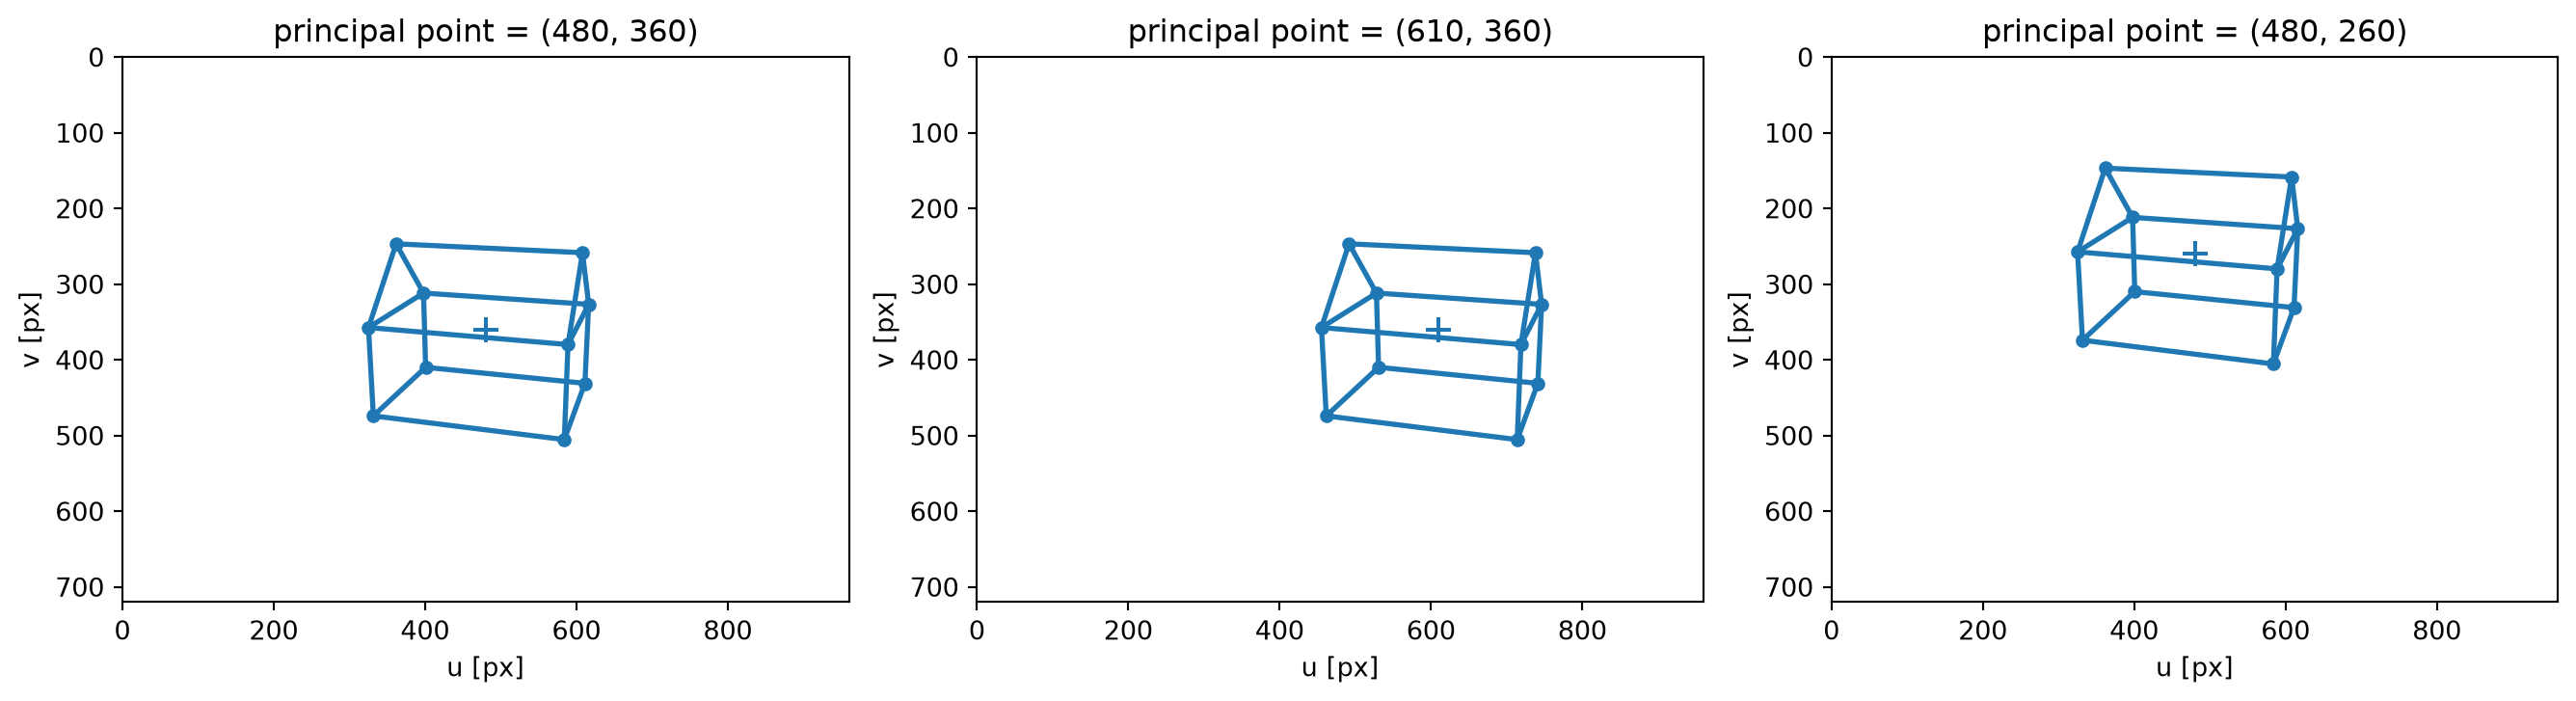

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (cx_i, cy_i) in zip(
    axes,
    [(width/2, height/2), (width/2 + 130, height/2), (width/2, height/2 - 100)]
):
    Ki = K_matrix(850, cx=cx_i, cy=cy_i)
    q, _ = project_points(X, Ki, R, t)
    draw_image_wireframe(ax, q, f"principal point = ({cx_i:.0f}, {cy_i:.0f})", width, height)
    ax.scatter([cx_i], [cy_i], marker="+", s=90)
plt.tight_layout()
plt.show()


## Intrinsics versus extrinsics

Changing $K$ changes the mapping **inside the camera** without moving the camera frame in space. Changing $(R,\mathbf t)$ changes the camera pose **without changing its internal calibration**.

Below $K$ is fixed while three cameras observe the same house. Their centres and coordinate axes make the extrinsic change explicit.


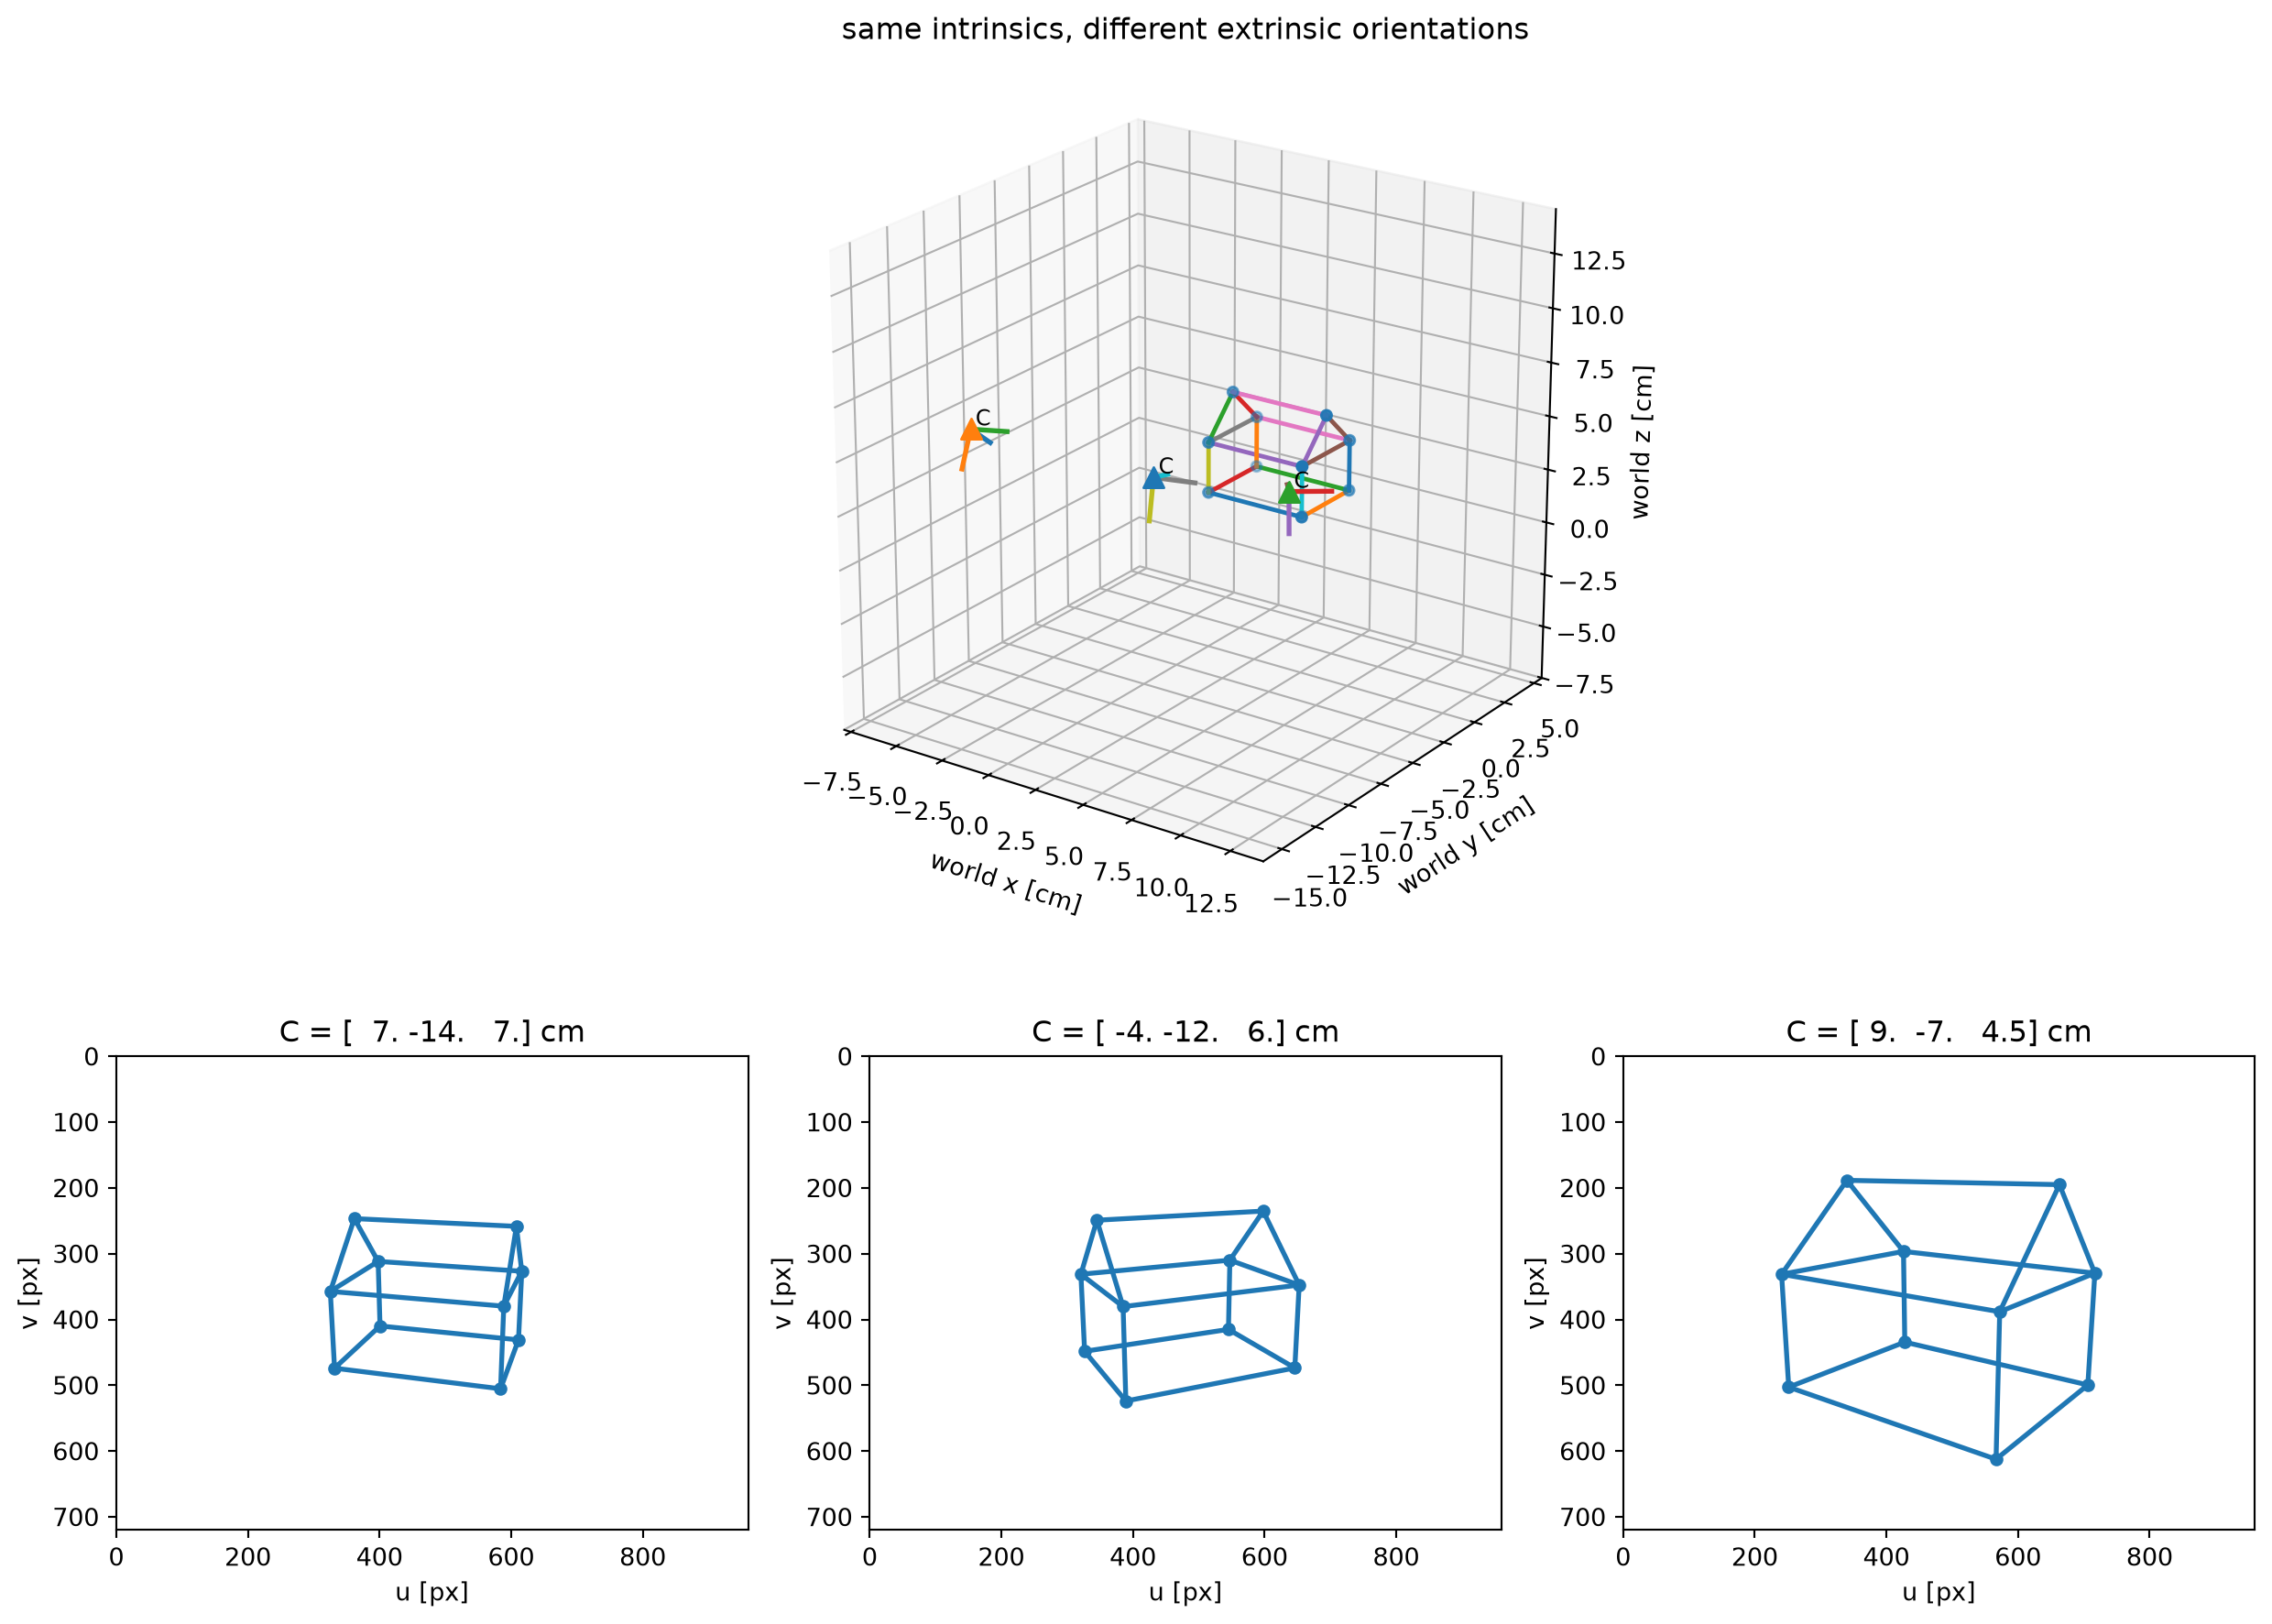

In [11]:
camera_positions = [
    [7.0, -14.0, 7.0],
    [-4.0, -12.0, 6.0],
    [9.0, -7.0, 4.5],
]

fig = plt.figure(figsize=(13, 10))
ax3 = fig.add_subplot(211, projection="3d")
draw_wireframe_3d(ax3, X)
for C_i in camera_positions:
    R_i, t_i = make_pose(C_i, target)
    draw_camera_frame(ax3, np.asarray(C_i), R_i, axis_length=1.8, label=False)
ax3.set_xlabel("world x [cm]")
ax3.set_ylabel("world y [cm]")
ax3.set_zlabel("world z [cm]")
ax3.set_title("same intrinsics, different extrinsic orientations")
ax3.view_init(elev=22, azim=-55)
set_axes_equal(ax3)

for j, C_i in enumerate(camera_positions, start=1):
    ax = fig.add_subplot(2, 3, 3+j)
    R_i, t_i = make_pose(C_i, target)
    q, _ = project_points(X, K, R_i, t_i)
    draw_image_wireframe(ax, q, f"C = {np.round(C_i,1)} cm", width, height)

plt.tight_layout()
plt.show()


## A pixel provides a ray

Calibration also lets us read the camera equation backwards. For a pixel $\widetilde{\mathbf m}=(u,v,1)^\top$,

$$
\mathbf d_c\propto K^{-1}\widetilde{\mathbf m}
$$

is the direction of its optical ray in the camera frame. In world coordinates,

$$
\mathbf d_w\propto R^\top K^{-1}\widetilde{\mathbf m}.
$$

The 3D point could be **anywhere** on

$$
\mathbf M(\alpha)=\mathbf C+\alpha\mathbf d_w.
$$

This is the geometric information lost by the perspective division: one image point represents an entire 3D ray.


pixel of X8: [361.666 246.714]
pixels of three other points on the same ray:
 [[361.666 246.714]
 [361.666 246.714]
 [361.666 246.714]]


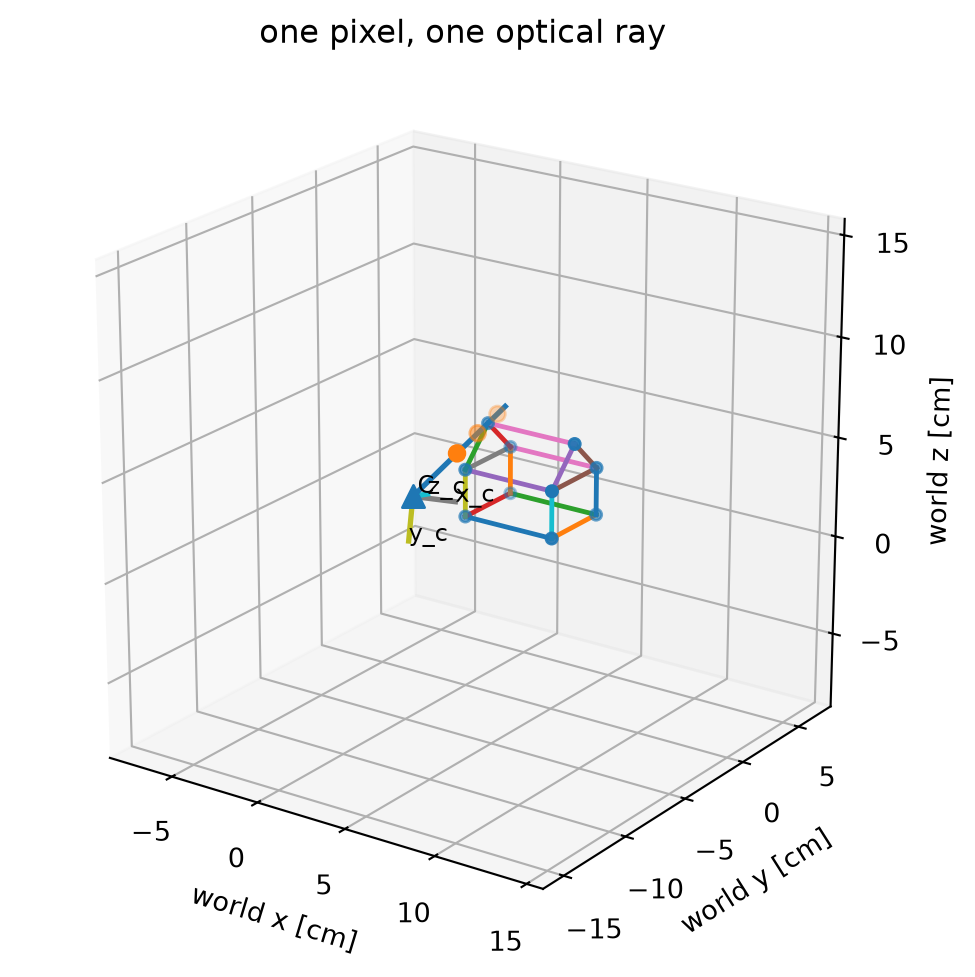

In [12]:
# Take the image of the left ridge point X8.
j = index["X8"]
x8 = np.r_[xy[j], 1.0]

d_cam = np.linalg.inv(K) @ x8
d_world = R.T @ d_cam
d_world /= np.linalg.norm(d_world)

# Verify numerically that different points on this ray project to the same pixel.
alphas = np.array([10.0, 15.0, 20.0])
ray_points = Ccam + alphas[:, None] * d_world
ray_pixels, _ = project_points(ray_points, K, R, t)

print("pixel of X8:", np.round(xy[j], 3))
print("pixels of three other points on the same ray:\n", np.round(ray_pixels, 3))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
draw_wireframe_3d(ax, X)
draw_camera_frame(ax, Ccam, R, axis_length=2.0)
Pline = np.vstack([Ccam, Ccam + 22*d_world])
ax.plot(Pline[:, 0], Pline[:, 1], Pline[:, 2], lw=2)
ax.scatter(ray_points[:, 0], ray_points[:, 1], ray_points[:, 2], s=35)
ax.set_title("one pixel, one optical ray")
ax.set_xlabel("world x [cm]")
ax.set_ylabel("world y [cm]")
ax.set_zlabel("world z [cm]")
ax.view_init(elev=21, azim=-55)
set_axes_equal(ax)
plt.show()


## Back to a real camera

The synthetic experiment is controlled: the house, $K$, $R$, and $\mathbf t$ are all known. Now we make one connection to the physical origami house.

For the iPhone sequence, a COLMAP reconstruction estimated a single `SIMPLE_RADIAL` camera. On the original 4032×3024 raster its focal length is about 3188 px and its principal point is essentially the image centre. The image stored with this notebook is a rotated and uniformly resized copy, so the calibration is transformed to that displayed raster as well.

To make the overlay below we fit only the **exterior orientation** of the ideal house to six visible vertices. That pose-estimation step is not the subject of this notebook; it is used here as a sanity check for the camera model.

::: {.callout-note}
The real folded house is not exactly the ideal $5.0\times3.8\times4.2$ cm wireframe. A small mismatch is expected — and useful.
:::


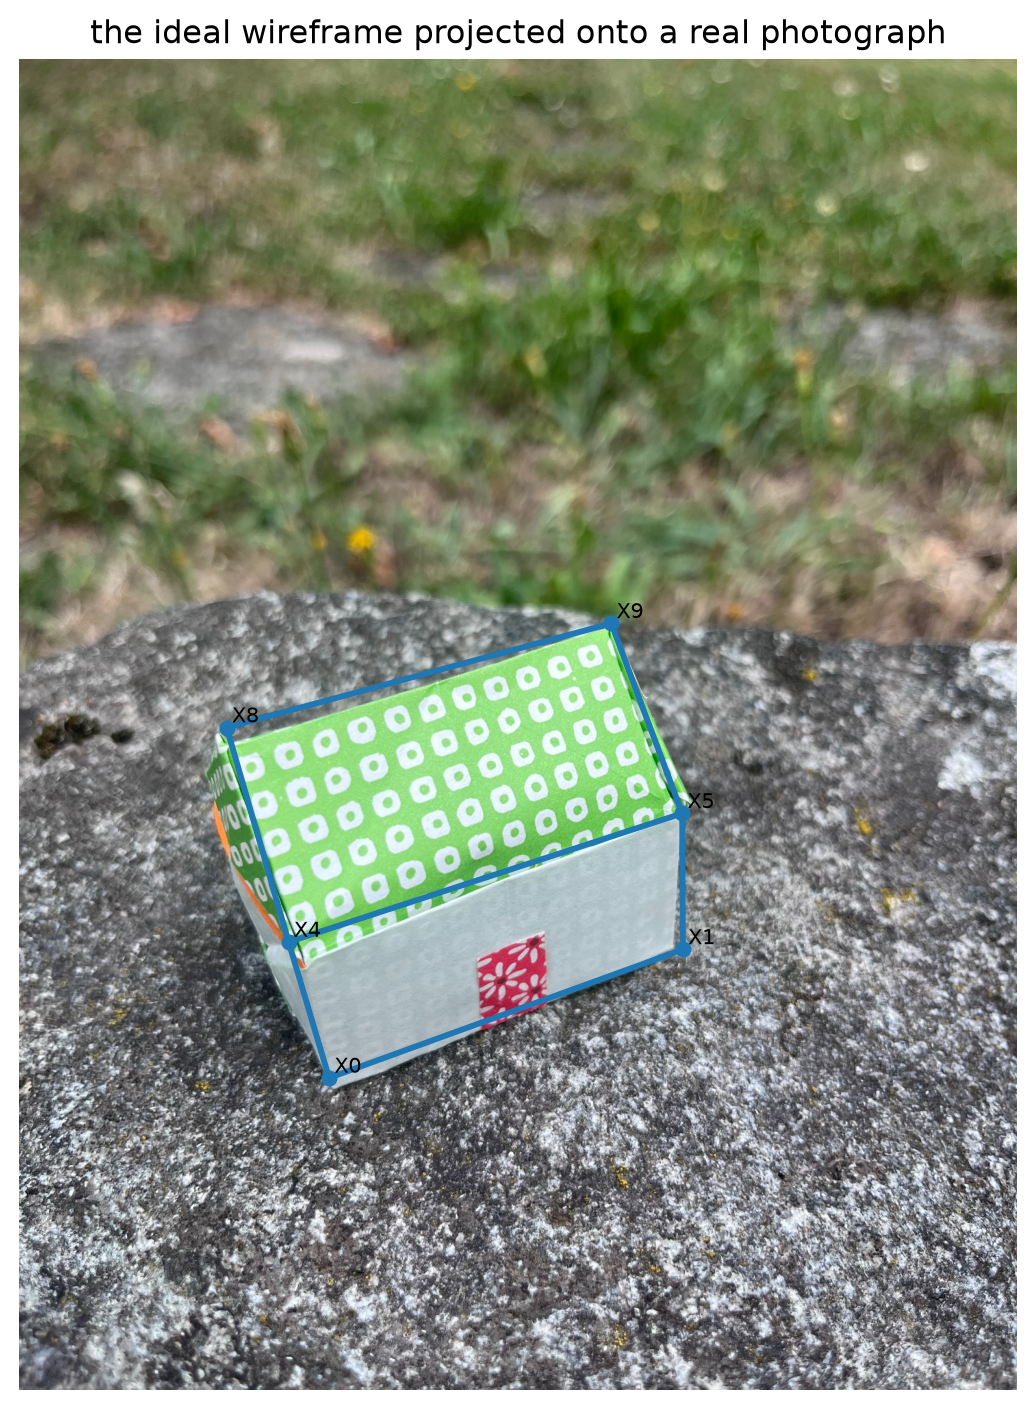

mean fit error on the six visible vertices: 11.5 px


In [13]:
with open(ROOT / "data/dojo_house/annotations/IMG_4337_camera_overlay.json") as f:
    real = json.load(f)

img = plt.imread(ROOT / "data/dojo_house/selected/IMG_4337.jpeg")
intr = real["intrinsics_display"]
K_real = K_matrix(intr["fx"], intr["fy"], intr["cx"], intr["cy"])
k1 = intr["k1"]
R_real = np.array(real["pose_ideal_house_to_camera"]["R"])
t_real = np.array(real["pose_ideal_house_to_camera"]["t"])


def project_simple_radial(X, K, R, t, k1):
    Xc = (R @ np.asarray(X).T).T + np.asarray(t)
    p = Xc[:, :2] / Xc[:, 2, None]
    r2 = np.sum(p*p, axis=1)
    p_dist = p * (1.0 + k1*r2)[:, None]
    ph = np.c_[p_dist, np.ones(len(p_dist))]
    x = (K @ ph.T).T
    return dehomogenize(x)

xy_real = project_simple_radial(X, K_real, R_real, t_real, k1)

fig, ax = plt.subplots(figsize=(7, 9))
ax.imshow(img)
visible_edges = [
    ("X0", "X1"), ("X1", "X5"), ("X5", "X4"), ("X4", "X0"),
    ("X4", "X8"), ("X8", "X9"), ("X9", "X5"),
]
edge_color = None
for a, b in visible_edges:
    q = xy_real[[index[a], index[b]]]
    line, = ax.plot(q[:, 0], q[:, 1], lw=2.2, color=edge_color)
    if edge_color is None:
        edge_color = line.get_color()
for k in real["pose_fit_vertices"]:
    q = xy_real[index[k]]
    ax.scatter(q[0], q[1], s=25, color=edge_color)
    ax.text(q[0] + 8, q[1] - 8, k, fontsize=8)
ax.set_title("the ideal wireframe projected onto a real photograph")
ax.axis("off")
plt.show()

print(f"mean fit error on the six visible vertices: {real['mean_reprojection_error_px']:.1f} px")


The same chain

$$
\widetilde{\mathbf M}
\xmapsto{G}
\widetilde{\mathbf M}_c
\xmapsto{[I|0]}
\lambda\widetilde{\mathbf p}
\xmapsto{K}
\lambda\widetilde{\mathbf m}
$$

that projected the synthetic house also explains where a metric 3D model should appear in a real photograph. The pinhole camera is therefore a map between **metric 3D geometry and pixels**, not just a drawing of rays through a hole.


## What the pinhole model leaves out

The pinhole camera is the geometric core, not the whole imaging pipeline. Real cameras also have lens distortion, focus and aperture effects, rolling shutter, image stabilization, and substantial computational processing.

For the geometry in this notebook the first correction that matters is usually **lens distortion**. The real overlay above includes one radial-distortion parameter; all preceding experiments intentionally used the ideal pinhole model.


## Exercises

### 1. Homogeneous coordinates

Take one vertex and compute $\mathbf y=P\widetilde{\mathbf M}$. Why can we not plot the first two entries of $\mathbf y$ directly? What happens if we replace $\mathbf y$ by $7\mathbf y$?

::: {.callout-tip collapse="true" title="Answer"}
The vector $\mathbf y=(a,b,c)^\top$ represents a point in $\mathbb P^2$, not Euclidean pixel coordinates. We must dehomogenize it:

$$
(u,v)=\left(\frac{a}{c},\frac{b}{c}\right).
$$

Multiplying by any non-zero scalar changes the representative but not the projective point, because

$$
\pi(7a,7b,7c)=\pi(a,b,c).
$$
:::

### 2. Perspective versus orthographic projection

Translate the whole house along the camera $z_c$ axis without changing its orientation. What changes in a perspective image? What changes in an orthographic image?

::: {.callout-tip collapse="true" title="Answer"}
In perspective projection every point is divided by its own depth $Z_c$, so moving the house farther away makes it smaller. In orthographic projection there is no depth division, so a pure translation along the viewing direction leaves the 2D shape and size unchanged.
:::

### 3. Focal length

Keep $(R,\mathbf t)$ fixed and double the focal length. Which quantities change, and which do not?

::: {.callout-tip collapse="true" title="Answer"}
The camera centre, camera axes, camera-frame coordinates, and normalized image coordinates do not change. Pixel displacements from the principal point are multiplied by two because only $K$ changed.
:::

### 4. One pixel, one ray

Pick another projected vertex, compute $K^{-1}\widetilde{\mathbf m}$, and verify numerically that several 3D points along the resulting ray project to the same pixel.

::: {.callout-tip collapse="true" title="Answer"}
$K^{-1}\widetilde{\mathbf m}$ gives a direction in the camera frame. After rotating it back to the world frame, every point

$$
\mathbf M(\alpha)=\mathbf C+\alpha R^\top K^{-1}\widetilde{\mathbf m}
$$

lies on the same optical ray and therefore has the same image point after dehomogenization.
:::

### 5. Principal point

Deliberately use the wrong principal point in the real-image overlay. How does the error appear geometrically if the pose is kept fixed?

::: {.callout-tip collapse="true" title="Answer"}
Changing $(c_x,c_y)$ changes the image reference system. With a fixed pose, the whole predicted projection is shifted in pixels by the same principal-point offset. If the pose were re-estimated, some of that error could be partially absorbed by the extrinsics, which is why calibration and pose should be conceptually separated.
:::


---

**Luca Magri** — Computer Vision Dojo  
Code MIT · text and figures CC BY-NC-ND 4.0  
<https://magrilu.github.io/cv-dojo/>
